In [1]:
import os 
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
import torch 
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)
from omegaconf import OmegaConf
import torch 
import numpy as np
import random
from compo_predictive_learning.models import create_model
import hydra
import logging
from collections import defaultdict
from compo_predictive_learning.datasets import make_sketch_dataloaders
logger = logging.getLogger(__name__)


In [2]:

def set_seed(seed=0):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

np.set_printoptions(precision=5, suppress=True, linewidth=200)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [5]:
from hydra import initialize, initialize_config_module, initialize_config_dir, compose

with initialize_config_dir(version_base=None, config_dir="/home/ghb24/paper_git/er/comp_predictive_learning/scripts/configs"):
    config = compose(config_name="train_rnn.yaml")


In [6]:
set_seed(config.seed)   
pretrain_loader,val_loader, smaller_pretrain_loader,analysis_loader,classification_metric_train_loaders, classification_metric_val_loaders,latent_names, train_contexts,val_contexts = make_sketch_dataloaders(config)

all_contexts = train_contexts + val_contexts

model = create_model(config).to(DEVICE)


--- Generating Support: 'full' ---
Total contexts: 54
Train contexts: 43
Validation contexts: 11


/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/torch/utils/data/sampler.py:76: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Output shape from conv layers 1024


In [7]:
    

# print(model)
# optimizer = torch.optim.AdamW(model.parameters(),lr=config.train_loop.pretrain_lr,weight_decay=config.train_loop.pretrain_decay)

# logger.info("-----------------")
# logger.info("Pretraining")
# logger.info("-----------------")

# metrics = defaultdict(list)

# logging_groups =  {}
    
# model,training_losses, validation_losses, metrics = train_loop(config,
#                                                             pretrain_loader,
#                                                             val_loader,
#                                                             smaller_pretrain_loader,
#                                                             analysis_loader,
#                                                             model,
#                                                             optimizer,
#                                                             all_contexts,
#                                                             latent_names,
#                                                             classification_metric_train_loaders,
#                                                             classification_metric_val_loaders,
#                                                             logger=print)
    


In [14]:
# model.load_state_dict(torch.load("/home/ghb24/comp_predictive_learning/test/contextual_full_1_0.8/sketch_6/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2, 3, 4, 5]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_256_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.001_0.01_0_0_128/seed0/model_step_4999.pth"))

model.load_state_dict(torch.load("/home/ghb24/paper_git/comp_predictive_learning/revieww/contextual_full_1_0.8/sketch_6/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2, 3, 4, 5]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_512_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.001_0.01_0_0_128/seed0/model_step_4999.pth"))
# model.load_state_dict(torch.load("/home/ghb24/comp_predictive_learning/test/contextual_full_1_0.8/sketch_6_4/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_512_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.001_0.01_0_0_128/seed0/model_step_4999.pth"))

/tmp/ipykernel_695539/2793622195.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home/ghb24/paper_git/comp_predictive_learning/revieww

<All keys matched successfully>

Output shape from conv layers 1024
Optimal number of clusters: 13, Silhouette scores: [0.12488 0.10612 0.11349 0.13635 0.16305 0.18261 0.21426 0.23715 0.25243 0.26929 0.26379 0.27214 0.26215 0.25745 0.25869 0.25996 0.26111 0.25964 0.25303 0.25467 0.26108 0.25969 0.25388]


(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='Neuron Clusters', ylabel='Contexts'>)

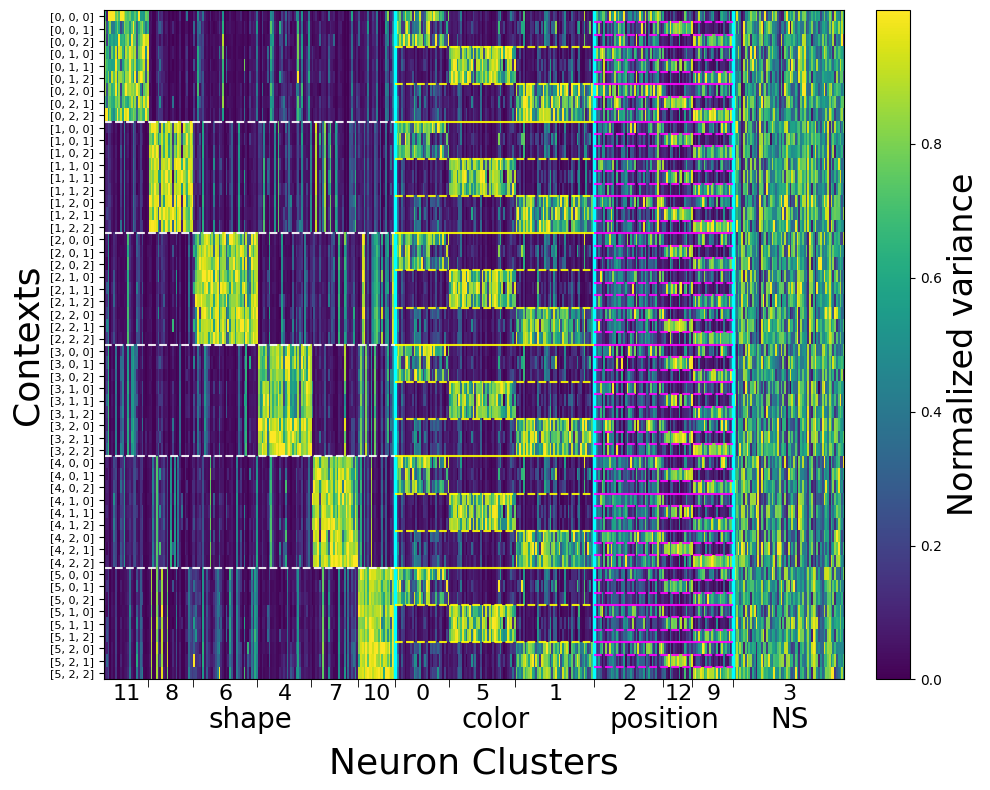

In [15]:
import matplotlib.pyplot as plt
from comp_predictive_learning.metrics.clustering import get_rnn_activities_and_sources_for_loader_for_clustering, get_optimal_n_cluster, analyze_and_sort_clusters, plot_sequentially_sorted_clusters

activations, contexts = get_rnn_activities_and_sources_for_loader_for_clustering(model, analysis_loader)
max_num_clusters, scores, norm_var_activities_per_context, active_units, labels = get_optimal_n_cluster(model, activations=activations, contexts=contexts, time_variance=False, device=DEVICE)
unique_contexts, inv = contexts.unique(dim=0, return_inverse=True)

print(f"Optimal number of clusters: {max_num_clusters}, Silhouette scores: {scores}")

(sorted_order, group_labels, group_boundaries,
peak_map, informative_indices, cluster_profiles) = analyze_and_sort_clusters(
    norm_var_activities_per_context=norm_var_activities_per_context.cpu().numpy(),
    contexts_unique=unique_contexts.cpu(),
    labels=labels,
    selectivity_threshold= 0.2,
    purity_threshold= 0.5
)
fig_cluster,ax_cluster = plt.subplots(1, 1, figsize=(10, 8))

plot_sequentially_sorted_clusters(
    norm_var_activities_per_context=norm_var_activities_per_context.cpu().numpy(),
    contexts_unique=unique_contexts.cpu(),
    labels=labels,
    final_cluster_order=sorted_order,
    group_labels=group_labels,
    group_boundaries_by_cluster_count=group_boundaries,
    group_name_map={"C0":"shape","C1":"color","C2":"position"},
    put_y_label= not "auto" in config.model.type,
    fig=fig_cluster,
    ax=ax_cluster
)


Output shape from conv layers 1024
Output shape from conv layers 1024
Cluster 0, original loss: 0.0003, new loss: 0.0016
Output shape from conv layers 1024
Cluster 1, original loss: 0.0003, new loss: 0.0022
Output shape from conv layers 1024
Cluster 2, original loss: 0.0003, new loss: 0.0005
Output shape from conv layers 1024
Cluster 3, original loss: 0.0003, new loss: 0.0035
Output shape from conv layers 1024
Cluster 4, original loss: 0.0003, new loss: 0.0010
Output shape from conv layers 1024
Cluster 5, original loss: 0.0003, new loss: 0.0023
Output shape from conv layers 1024
Cluster 6, original loss: 0.0003, new loss: 0.0011
Output shape from conv layers 1024
Cluster 7, original loss: 0.0003, new loss: 0.0007
Output shape from conv layers 1024
Cluster 8, original loss: 0.0003, new loss: 0.0009
Output shape from conv layers 1024
Cluster 9, original loss: 0.0003, new loss: 0.0013
Output shape from conv layers 1024
Cluster 10, original loss: 0.0003, new loss: 0.0009
Output shape from 

(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='Lesioned cluster', ylabel='Contexts'>)

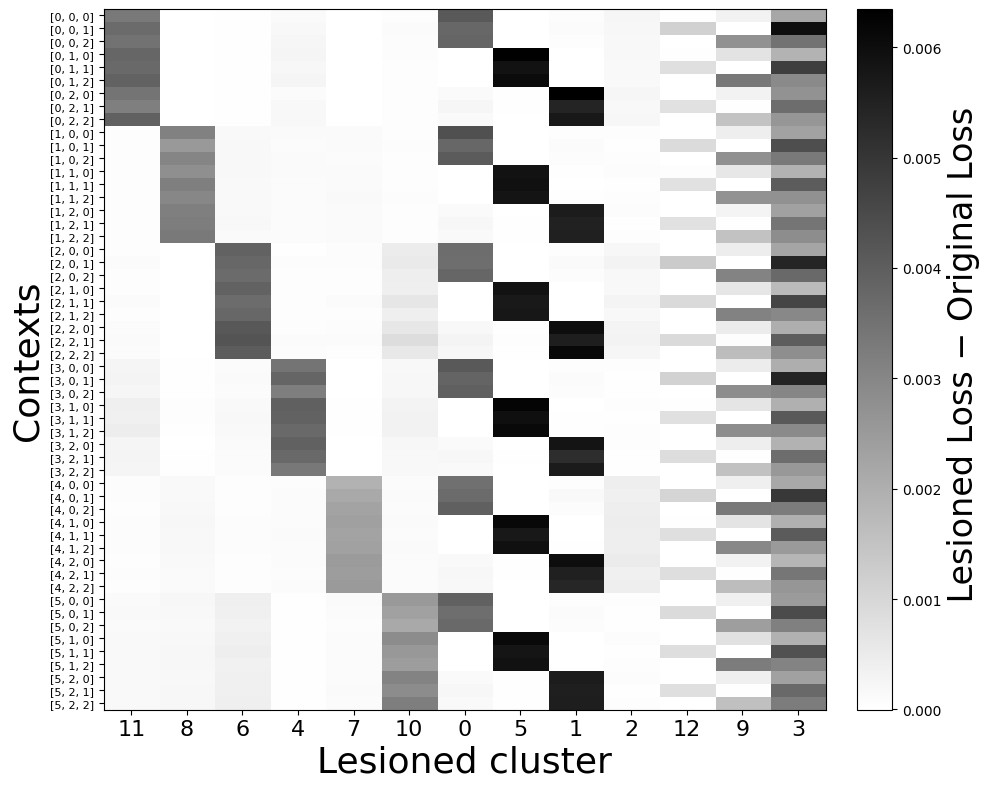

In [16]:
from comp_predictive_learning.metrics.clustering import computer_lesioned_cluster_losses,plot_cluster_lesion_delta

fig_lesion,ax_lesion = plt.subplots(1, 1, figsize=(10, 8))
cluster_losses, original_network_losses,cluster_to_neurons = computer_lesioned_cluster_losses(model,
                                                                        dataloader=analysis_loader,
                                                                        active_units=active_units,
                                                                        labels=labels,
                                                                        number_of_clusters=max_num_clusters)

plot_cluster_lesion_delta(
    original_network_losses=original_network_losses,
    lesioned_cluster_loss=cluster_losses,
    cluster_order=sorted_order, 
    put_y_label= not "auto" in config.model.type,
    fig=fig_lesion,
    ax=ax_lesion)


In [17]:
original_indices = np.where(active_units)[0]
cluster_to_neurons = {}
for i, cluster_id in enumerate(np.unique(labels)):
    neurons_in_cluster_mask = labels == cluster_id
    cluster_to_neurons[cluster_id] = original_indices[neurons_in_cluster_mask]

all_neurons_groups = {}
for k in cluster_to_neurons:
    all_neurons_groups[str(k)] = cluster_to_neurons[k]

for k in all_neurons_groups:
    print(f"Group {k} has {(all_neurons_groups[k])} neurons")
    
context_to_cluster = {}
curr_idx = 0
for i, gl in enumerate(group_labels):
    context_to_cluster[gl] = []
    for k in range(curr_idx, group_boundaries[i]):
        context_to_cluster[gl].append(sorted_order[k])
    curr_idx = group_boundaries[i]

context_to_neurons = {}
for gl in context_to_cluster:
    context_to_neurons[gl] = []
    for c in context_to_cluster[gl]:
        context_to_neurons[gl] += list(cluster_to_neurons[c])
    context_to_neurons[gl] = np.unique(context_to_neurons[gl])

Group 0 has [ 16  64  83  86 104 119 143 169 174 248 282 283 285 304 306 313 316 317 330 343 358 378 397 426 440 445 466 481 482 496] neurons
Group 1 has [  7  14  25  45  62  69  97  98 109 117 134 137 142 145 160 167 168 189 201 208 212 214 234 237 259 264 276 277 289 293 303 320 324 351 376 383 390 411 433 441 446 448 460 501] neurons
Group 2 has [ 10  21  36  48  50  81  90 126 150 153 163 173 176 179 192 205 223 232 243 266 279 309 328 332 336 357 393 413 415 428 437 452 459 470 472 479 488 497 504] neurons
Group 3 has [  2   4  11  12  40  41  75  79  92  95 103 128 129 146 155 166 180 188 206 207 210 221 233 246 251 255 260 262 265 267 273 275 281 288 299 329 338 341 342 346 347 348 352 354 360 363 400 423 424
 429 436 439 449 455 464 468 476 477 483 494 506 507] neurons
Group 4 has [  8  30  33  44  60 121 130 138 178 184 190 200 202 235 236 253 263 305 308 334 339 369 380 382 386 407 416 419 489 499] neurons
Group 5 has [ 20  24  42  77  87  94 112 113 122 144 147 157 196 227 

In [18]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap,MDS

class TrajectoryProjector:
    """Base class for projection strategies."""
    def fit_transform(self, data):
        """
        Args:
            data: Numpy array of shape (Batch * Time, Neurons)
        Returns:
            Projected data of shape (Batch * Time, 2)
        """
        raise NotImplementedError

class PCAProjector(TrajectoryProjector):
    def fit_transform(self, data):
        pca = PCA(n_components=2)
        return pca.fit_transform(data)

class IsomapProjector(TrajectoryProjector):
    def __init__(self, n_neighbors=15):
        self.n_neighbors = n_neighbors

    def fit_transform(self, data):
        # Isomap can be slow on large datasets; consider subsampling if needed
        iso = Isomap(n_components=2, n_neighbors=self.n_neighbors)
        return iso.fit_transform(data)

class TSNEProjector(TrajectoryProjector):
    def fit_transform(self, data):
        tsne = TSNE(n_components=2, init='pca', learning_rate='auto')
        return tsne.fit_transform(data)

class MDSProjector(TrajectoryProjector):
    def fit_transform(self, data):
        mds = MDS(n_components=2, random_state=42)
        return mds.fit_transform(data)

class UMAPProjector(TrajectoryProjector):
    def __init__(self, n_neighbors=15, min_dist=0.1):
        self.n_neighbors = n_neighbors
        self.min_dist = min_dist

    def fit_transform(self, data):
        import umap
        reducer = umap.UMAP(n_neighbors=self.n_neighbors, min_dist=self.min_dist)
        return reducer.fit_transform(data)
    

In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def get_activities_for_latent_dynamic(
    latent_idx,
    dynamic_idx,
    dataloader,
    model,
    context_to_cluster,
    cluster_to_neurons,
    device='cuda'
):
    
    # --- 1. Neuron Selection Logic ---
    latent_keys = list(context_to_cluster.keys())
    target_latent_key = latent_keys[latent_idx]
    
    # Get cluster and neurons
    target_cluster_id = context_to_cluster[target_latent_key][dynamic_idx]
    neuron_indices = cluster_to_neurons[target_cluster_id]
    
    print(f"Analyzing Latent: '{target_latent_key}' (Idx {latent_idx}) | Dynamic: {dynamic_idx}")
    print(f"Cluster ID: {target_cluster_id} | Neurons: {len(neuron_indices)}")

    # --- 2. Data Collection ---
    collected_activities = []
    collected_latents = []
    
    model.eval()
    
    with torch.no_grad():
        for batch in dataloader:
            inputs, latents, context = batch
            inputs = inputs.to(device)
            
            batch_dynamic_indices = context[:, latent_idx]
            mask = (batch_dynamic_indices == dynamic_idx)
            
            if mask.sum() == 0:
                print("No sequences found for this dynamic in the current batch, skipping...")
                continue

            rnn_act = model(inputs)[2].permute(1, 0, 2)
            
            latents = latents.permute(1, 0, 2)  # (B, T, Latents)
            filtered_acts = rnn_act[mask]       
            filtered_latents = latents[mask]    
            
            relevant_acts = filtered_acts[:, :, neuron_indices] 
            
            collected_activities.append(relevant_acts.cpu().numpy())
            collected_latents.append(filtered_latents.cpu().numpy())

    if not collected_activities:
        print("No sequences found.")
        return

    # Concatenate
    X = np.concatenate(collected_activities, axis=0) # (Total_Seq, Time, Neurons)
    L = np.concatenate(collected_latents, axis=0)    # (Total_Seq, Time, Latents)
    return X, L, target_latent_key, target_cluster_id, neuron_indices

def project_trajectories_and_take_one_per_ic(
    X, L,
    latent_idx,
    projection_strategy,
    start_from_second_activity=True,
    use_mean=False
):
    
    if start_from_second_activity:
        X = X[:,1:]
        L = L[:,1:]
    B, T, D = X.shape
    X_flat = X.reshape(B * T, D)
    
    print(f"Projecting {B} sequences...")
    X_proj_flat = projection_strategy.fit_transform(X_flat)
    X_proj = X_proj_flat.reshape(B, T, 2)

    initial_values = L[:, 0, latent_idx]
    
    # Round to group floating point differences
    unique_vals = np.unique(initial_values)    
    
    if use_mean:
        print(f"Calculating MEAN trajectory for {len(unique_vals)} unique initial conditions...")
        X_out_list = []
        L_out_list = []
        
        for val in unique_vals:
            # Find all batch indices that share this initial condition
            mask = (initial_values == val)
            
            X_mean = np.mean(X_proj[mask], axis=0)
            
            L_mean = np.mean(L[mask], axis=0)
            print(L_mean.shape)
            X_out_list.append(X_mean)
            L_out_list.append(L_mean)
            
        X_final = np.stack(X_out_list) # (Unique_ICs, Time, 2)
        L_final = np.stack(L_out_list) # (Unique_ICs, Time, Latents)
        
        # Generate dummy indices for compatibility with plotting function
        indices_proxy = np.arange(len(unique_vals))
        
    else:
        print(f"Selecting SINGLE trajectory for {len(unique_vals)} unique initial conditions...")
        _, unique_indices = np.unique(initial_values, return_index=True)
        
        X_final = X_proj[unique_indices]
        L_final = L[unique_indices]
        indices_proxy = unique_indices    
        
    return X_final, L_final, unique_vals, indices_proxy

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

def plot_trajectories_with_latent_values(
    X_proj_unique,
    L_unique,
    unique_vals,
    unique_indices,
    target_latent_key,
    latent_idx,
    num_initial_conditions_to_plot=-1,
    title='',
    annotate=True,
    annotate_every=1,          # e.g. 2 or 3 to reduce text clutter
    annotate_offset=(0.0, 0.0) # small offset if labels overlap, e.g. (0.01, 0.01)
):
    fig, ax = plt.subplots(figsize=(12, 9))

    # How many to plot
    n_total = len(unique_indices)
    n_plot = min(n_total, num_initial_conditions_to_plot) if num_initial_conditions_to_plot and num_initial_conditions_to_plot > 0 else n_total

    # Nicer colormap than jet
    cmap = cm.viridis
    colors = cmap(np.linspace(0, 1, n_plot))

    # A bit cleaner default styling
    ax.set_facecolor("white")
    ax.grid(True, alpha=0.25, linewidth=0.8)

    for i in range(n_plot):
        x_traj = X_proj_unique[i, :, 0]
        y_traj = X_proj_unique[i, :, 1]
        traj_latent_values = L_unique[i, :, latent_idx]

        init_val = unique_vals[i]
        color = colors[i]

        # Line
        ax.plot(x_traj, y_traj, color=color, alpha=0.75, linewidth=2)

        # Points (light)
        ax.scatter(x_traj, y_traj, color=color, s=18, alpha=0.35, linewidths=0)

        # Start marker: triangle
        ax.scatter(
            x_traj[0], y_traj[0],
            marker="^", s=70,
            facecolor=color, edgecolor="black", linewidth=0.8,
            zorder=5
        )

        # End marker: rectangle (square marker)
        ax.scatter(
            x_traj[-1], y_traj[-1],
            marker="s", s=70,
            facecolor=color, edgecolor="black", linewidth=0.8,
            zorder=5
        )

        # One legend entry per trajectory (use the line handle)
        ax.plot([], [], color=color, linewidth=3, label=f"Init: {init_val:.2f}")

        # Optional text annotations
        if annotate:
            dx, dy = annotate_offset
            for t in range(0, len(x_traj), max(1, int(annotate_every))):
                ax.text(
                    x_traj[t] + dx, y_traj[t] + dy,
                    f"{traj_latent_values[t]:.2f}",
                    fontsize=7,
                    alpha=0.85,
                    color="black",
                    ha="center", va="bottom"
                )

    # Formatting
    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel("Dimension 1", fontsize=12)
    ax.set_ylabel("Dimension 2", fontsize=12)

    # Keep aspect visually reasonable
    ax.margins(0.05)

    # Compact legend
    leg = ax.legend(
        title=f"Initial {target_latent_key}",
        loc="best",
        fontsize="small",
        title_fontsize="small",
        frameon=True,
        framealpha=0.9
    )
    leg.get_frame().set_linewidth(0.0)

    plt.tight_layout()
    plt.show()

In [20]:
from compo_predictive_learning.datasets import make_contextual_loader
all_contexts = train_contexts + val_contexts 
config.dataset.sequence_length = 10
config.train_loop.batch_size = 32
analysis_loader = make_contextual_loader(config=config,context_vals=all_contexts,num_sample_per_context=32,context_vector_size=3,context_start_idx=0,shuffle=False)



In [21]:
from copy import deepcopy
rnn_cfg = deepcopy(model.rnn_cfg)
rnn_cfg.noise = 0.0
noiseless_model = model.create_new_instance(new_params={'rnn_cfg': rnn_cfg}).to(DEVICE)

latent_idx = 1
dynamic_idx = 1


Output shape from conv layers 1024


In [22]:
X, L, target_latent_key, target_cluster_id, neuron_indices = get_activities_for_latent_dynamic(
    latent_idx=latent_idx,
    dynamic_idx=dynamic_idx,
    dataloader=analysis_loader,
    model=noiseless_model,
    context_to_cluster=context_to_cluster,
    cluster_to_neurons=cluster_to_neurons,
    device=DEVICE
)

Analyzing Latent: 'C1' (Idx 1) | Dynamic: 1
Cluster ID: 5 | Neurons: 37
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found

In [23]:
X_proj_unique, L_unique, unique_vals, unique_indices = project_trajectories_and_take_one_per_ic(X,
                                                                                                L,
                                                                                                latent_idx=latent_idx,
                                                                                                projection_strategy=MDSProjector(),
                                                                                                start_from_second_activity=True,
                                                                                                use_mean=False)



Projecting 576 sequences...
Selecting SINGLE trajectory for 1 unique initial conditions...


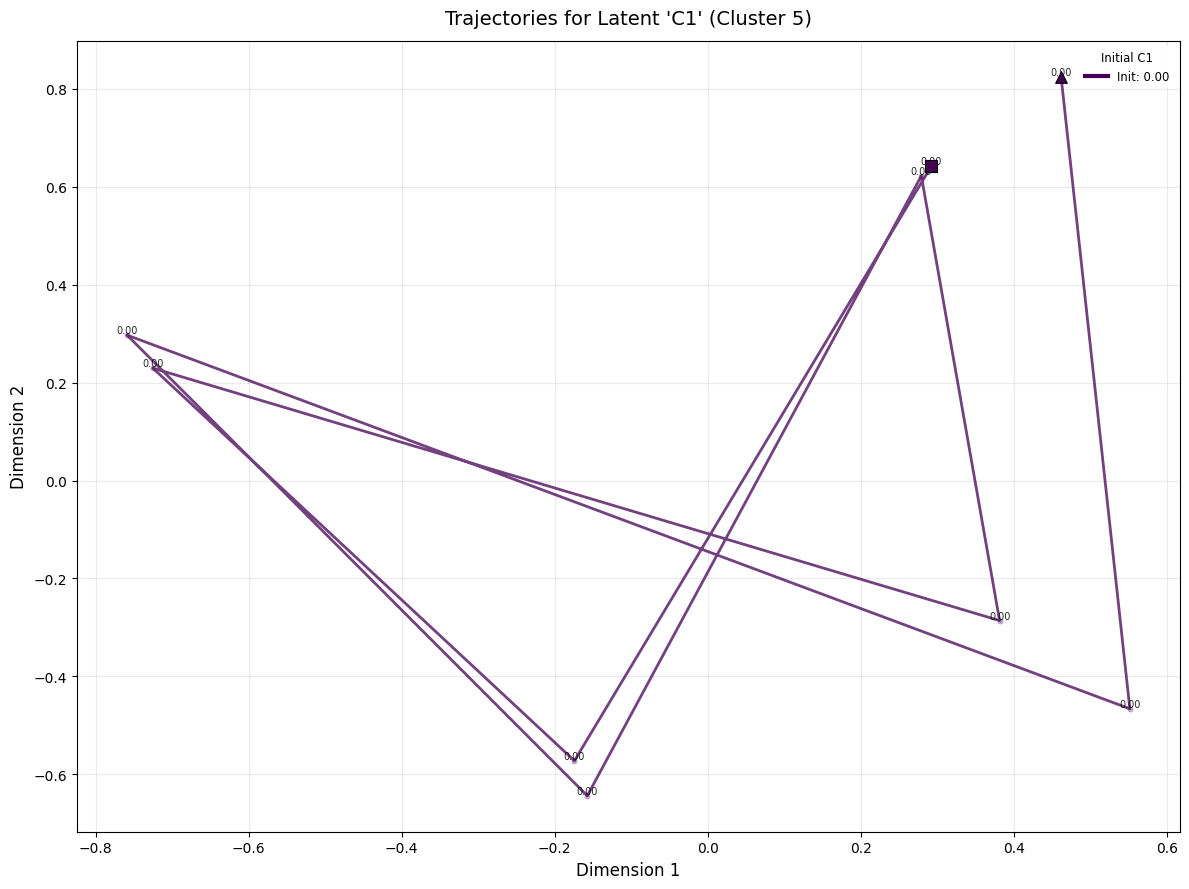

In [24]:
plot_trajectories_with_latent_values(
    X_proj_unique,
    L_unique,
    unique_vals,
    unique_indices,
    target_latent_key,
    latent_idx,
    num_initial_conditions_to_plot=1,
    title=f"Trajectories for Latent '{target_latent_key}' (Cluster {target_cluster_id})",
)



In [ ]:
import torch 
from sklearn.svm import LinearSVC
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def unpack_batch(batch):
    prim_sequence_inputs, latents = batch
    prim_sequence_inputs = prim_sequence_inputs.transpose(0,1).to(DEVICE)
    latents = latents.transpose(0,1).to(DEVICE)
    return prim_sequence_inputs, latents

def get_neurons_for_latent(
            config,
             model,
             train_loader,
             val_loader,
             idx_to_classify,
             neurons_to_keep = None):
    
    model.train()
    def get_activity_and_labels_b(loader):
        acti = []
        labels = []
        with torch.no_grad():
            for batch in loader:
                prim_sequence_inputs, latents = unpack_batch(batch)
                _,_,activity,_ = model(prim_sequence_inputs)
                acti.append(activity[-1:].cpu().flatten(0,1))
                labels.append(latents[-1:].cpu().flatten(0,1))
        return torch.cat(acti, dim=0), torch.cat(labels, dim=0)

    train_activities, train_latents = get_activity_and_labels_b(train_loader)
    val_activities, val_latents = get_activity_and_labels_b(val_loader)
    
    if neurons_to_keep is not None:
        train_activities = train_activities[...,neurons_to_keep]
        val_activities = val_activities[...,neurons_to_keep]

    classifier =  LinearSVC(max_iter=5000,penalty="l1",C=10)
    classifier.fit(train_activities.numpy(), train_latents[:,idx_to_classify].cpu().numpy())
    train_acc = classifier.score(train_activities.numpy(), train_latents[:,idx_to_classify].cpu().numpy())
    val_acc = classifier.score(val_activities.numpy(), val_latents[:,idx_to_classify].cpu().numpy())

    neurons = np.where(classifier.coef_.sum(axis=0)!=0)[0]
    print(classifier.coef_.sum(axis=0).shape)
    print(classifier.coef_.shape)
    print(f"Latent {idx_to_classify}, train acc: {train_acc}, val acc: {val_acc}, num neurons: {len(neurons)}")
    if neurons_to_keep is not None:
        index_after_removing_to_orignal_index = {}
        for i, neuron in enumerate(neurons_to_keep):
            index_after_removing_to_orignal_index[i] = neuron
        neurons = [index_after_removing_to_orignal_index[n] for n in neurons]
    return neurons



In [ ]:
get_neurons_for_latent(config,model,classification_metric_train_loaders[0]["primitive"][0],classification_metric_val_loaders[0]["primitive"][0],0)


In [ ]:
context_to_neurons

In [10]:
def get_neurons_coding_for_latent_except_from_cluster(latent,
                                                      cluster_to_neurons,
                                                      latent_to_clusters,
                                                      clusters_to_exclude=[]):

    neurons = []
    for c in latent_to_clusters[latent]:
        if c in clusters_to_exclude:
            continue
        neurons += list(cluster_to_neurons[c])
    return np.unique(neurons)        


In [11]:
def get_neurons_of_clusters(cluster_to_neurons,clusters):
    neurons = []
    for c in clusters:
        neurons += list(cluster_to_neurons[c])
    return np.unique(neurons)

def get_neurons_except_from_clusters(cluster_to_neurons,clusters):
    all_neurons = []
    for c in cluster_to_neurons:
        all_neurons += list(cluster_to_neurons[c])
    all_neurons = np.unique(all_neurons)
    neurons_to_remove = get_neurons_of_clusters(cluster_to_neurons,clusters)
    neurons_to_keep = [n for n in all_neurons if n not in neurons_to_remove]
    return np.array(neurons_to_keep)

In [12]:
from comp_predictive_learning.datasets import make_dataset_contextual_sketch, make_contextual_loader
def make_disentanglement_loaders_with_timesteps(num_timesteps,contexts):
    def make_abstract_loader(train_or_val,test_latent):
        ds = make_dataset_contextual_sketch(1,
                                            config,
                                            task_disentanglement=True,
                                            task_disentanglement_train_set=train_or_val,
                                            task_disentanglement_latent=test_latent,
                                            task_disentanglement_contexts=contexts,
                                            task_disentanglement_num_timesteps=num_timesteps)
        loader = torch.utils.data.DataLoader(ds,
                                            batch_size=config.train_loop.batch_size,
                                            num_workers=0,
                                            shuffle=False,
                                            drop_last=False,
                                            pin_memory=False)
        return loader

    classification_metric_train_loaders = {}
    classification_metric_val_loaders = {}
    latents = []
    for lat_idx, lat in enumerate(["primitive","scale","color","position"]):
        if lat == "scale":
            if len(config.dataset.scales) == 1:
                continue 
        if lat == "color":
            if len(config.dataset.colors) == 1:
                continue
        latents.append(lat)
        classification_metric_train_loaders[lat] = (make_abstract_loader(True,lat),lat_idx) 
        classification_metric_val_loaders[lat] = (make_abstract_loader(False,lat),lat_idx) 
    return classification_metric_train_loaders, classification_metric_val_loaders


In [13]:
cluster_per_latent_per_dynamic = []
start = 0
for end in group_boundaries:
    cluster_per_latent_per_dynamic.append((sorted_order[start:end]))
    start = end

In [74]:
import copy 
def get_representations_for_context_aggregated_by_first_latents(
            config,
             model,
             analysis_loader,
             cluster_per_latent_per_dynamic,
             cluster_to_neurons,
             latent_to_look_at,
             dynamic_to_look_at=0):
    
    model.train()
    
    for b in  analysis_loader:
        inputs,latents,context = b
        current_dynamic = context[0,latent_to_look_at]
        if current_dynamic.item() == dynamic_to_look_at:
            break
    neurons_idx = cluster_to_neurons[cluster_per_latent_per_dynamic[latent_to_look_at][current_dynamic.item()]]
    print(f"Using dynamic {current_dynamic.item()} for latent {latent_to_look_at}, num neurons: {len(neurons_idx)}")
    rnn_cfg = copy.deepcopy(model.rnn_cfg)
    rnn_cfg.noise = 0.0
    noiseless_model = model.create_new_instance(new_params={'rnn_cfg': rnn_cfg}).to(DEVICE)

    rnn_act = noiseless_model(inputs)[2]
    act_per_first_latent = defaultdict(list)
    latent_per_first_latent = defaultdict(list)
    for i in range(inputs.shape[1]):
        first_latent = latents[0,i,latent_to_look_at].item()
        act_per_first_latent[first_latent].append(rnn_act[:,i,neurons_idx].detach().cpu())
        latent_per_first_latent[first_latent].append(latents[:,i,latent_to_look_at].detach().cpu())
        
    return act_per_first_latent,latent_per_first_latent

In [75]:
from comp_predictive_learning.datasets import make_contextual_loader
context_size = 3
config.dataset.sequence_length = 10
analysis_loader = make_contextual_loader(config=config,dataset_name="sketch",context_vals=all_contexts,num_sample_per_context=128,context_vector_size=context_size,context_start_idx=0,shuffle=False)


Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random drawings.
Using primitives: ['h_line', 'v_line', 'circle', 'semi_circle', 'cross', 'triangle', 'square']
Generated 128 random dr

In [65]:
dynamic_to_look_at = 2
latent_to_look_at = 0

In [76]:
act_per_first_latent,latent_per_first_latent = get_representations_for_context_aggregated_by_first_latents(config,
                                                            model,
                                                            analysis_loader,
                                                            cluster_per_latent_per_dynamic,
                                                            cluster_to_neurons,
                                                            latent_to_look_at=0,
                                                            dynamic_to_look_at=dynamic_to_look_at)

Using dynamic 2 for latent 0, num neurons: 47
Output shape from conv layers 1024


In [67]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
import umap



In [77]:
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

def get_latent_colors(dicti):
    """
    Map each latent id -> a distinct RGBA color using matplotlib categorical colormaps.
    """
    latent_ids = sorted(act_per_first_latent.keys())
    K = len(latent_ids)

    if K <= 10:
        cmap = get_cmap("tab10")
    elif K <= 20:
        cmap = get_cmap("tab20")
    else:
        cmap = get_cmap("hsv")

    return {k: cmap(i % cmap.N) for i, k in enumerate(dicti)}

# --- PCA prep ----------------------------------------------------------------

def get_first_activity_per_latent_and_remove_first_step(act_per_first_latent):
    # first activity only, shape [T_k, N] each
    return {k: v[0][1:] for k, v in act_per_first_latent.items()}


In [79]:
first_act = get_first_activity_per_latent_and_remove_first_step(act_per_first_latent)
first_latent = get_first_activity_per_latent_and_remove_first_step(latent_per_first_latent)
X = torch.cat([v for k, v in first_act.items()], dim=0).numpy()

In [70]:
def fit_and_get_projection(act_per_latent):
    num_step_per_act = act_per_latent[list(act_per_latent.keys())[0]].shape[0]
    X = torch.cat([v for k, v in act_per_latent.items()], dim=0).numpy()
    projected = MDS(n_components=2, random_state=42).fit_transform(X)
    proj_dict = {}
    for i, k in enumerate(act_per_latent):
        proj_dict[k] = projected[i*num_step_per_act:(i+1)*num_step_per_act]
    return proj_dict

In [71]:

projed_first_latent = fit_and_get_projection(first_act)
sorted_keys = sorted(projed_first_latent.keys())
projed_first_latent = {k: projed_first_latent[k] for k in sorted_keys}

In [ ]:
whole_sequence_colors = get_latent_colors(act_per_first_latent)


/tmp/ipykernel_2377023/2873430862.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10")


In [ ]:
latent_colors = 

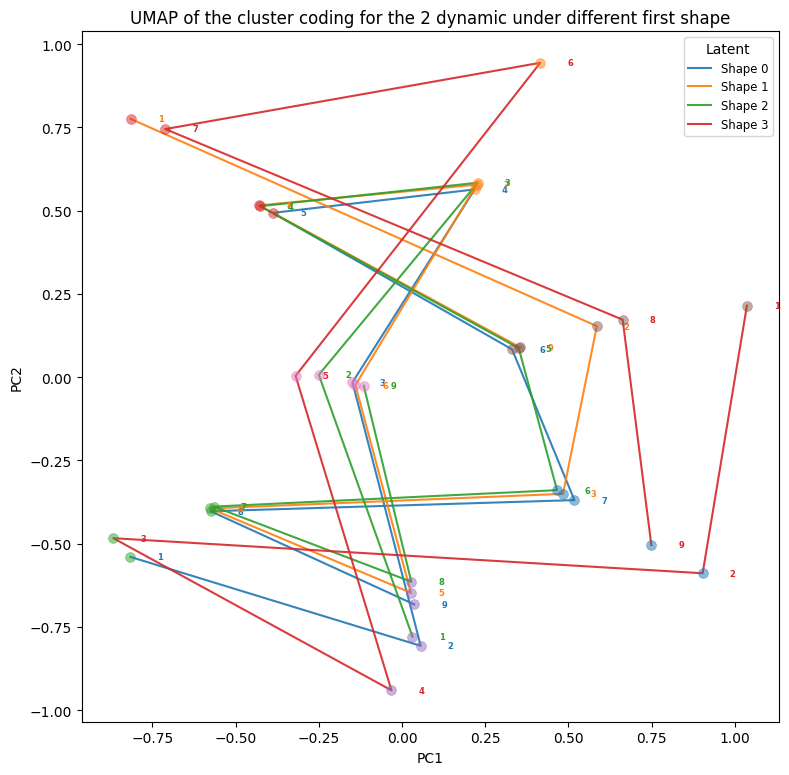

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

for k, S in projed_first_latent.items():
    if not (k == 0 or k == 1 or k == 2 or k == 3):
        continue

    latent_sequence = first_latent[k]
    # PC1/PC2 over time
    x = S[:, 0]
    y = S[:, 1]
    T_k = len(x)

    c_latent = latent_colors[k]

    # 1. plot the trajectory line in the latent's unique color
    ax.plot(
        x, y,
        linestyle="-",
        linewidth=1.5,
        color=c_latent,
        alpha=0.9,
        label=f"Shape {int(k)}",
    )

    # 2. label every timestep with its index (1,2,3,...)
    #    using a tiny offset so text isn't exactly on top of the line
    for t in range(T_k):
        col_dot = latent_colors[latent_sequence[t].item()]
        ax.scatter(
            x[t],
            y[t],
            marker="o",
            s=50,
            facecolors=col_dot,
            linewidths=0.5,
            zorder=4,
            alpha=0.5,
        )

        ax.text(
            x[t]+0.09,
            y[t],
            str(t + 1),          # <-- 1-based indexing
            color=c_latent,
            fontsize=6,
            ha="center",
            va="center",
            fontweight="bold",
        )

    # 3. emphasize start and end points for direction
    # ax.scatter(
    #     x[0], y[0],
    #     marker="o",
    #     s=50,
    #     facecolors=c_latent,
    #     edgecolors="k",
    #     linewidths=0.5,
    #     zorder=4,
    #     alpha=0.5,
    # )
    # ax.scatter(
    #     x[-1], y[-1],
    #     marker="s",
    #     s=50,
    #     facecolors=c_latent,
    #     edgecolors="k",
    #     linewidths=0.5,
    #     zorder=4,
    #     alpha=0.5,
    # )

# axes / legend
ax.set_xlabel("DIM1")
ax.set_ylabel("DIM2")
ax.set_title(f"MDS of the cluster coding for the {dynamic_to_look_at} dynamic under different first shape")
ax.set_aspect("equal")

ax.legend(fontsize="small", loc="best", title="Latent")

plt.tight_layout()
plt.show()
